# Phase 1: Exploratory Data Analysis
### Grower Impact & Data Quality Dashboard — Greenstand Treetracker

**Author:** Jueeli Sawant
**Status:** Using synthetic placeholder data (`generate_synthetic_data_v2.py`) pending live API/DB access. Column names match Greenstand's real Treetracker schema (`planter_id`, `country_name`, `lat`/`lon`, `captured_at`), so this notebook runs unchanged once real data is swapped in — only the CSV paths need to change.


In [1]:
import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
from data_access import load_captures, load_planters, DATA_SOURCE
import os
os.makedirs('../outputs', exist_ok=True)  # created automatically if missing

captures = load_captures()
planters = load_planters()

print("Data source:", DATA_SOURCE)
print("Captures:", captures.shape)
print("Planters:", planters.shape)
captures.head()

Data source: synthetic
Captures: (8095, 9)
Planters: (500, 10)


,capture_id,planter_id,captured_at,lat,lon,species,country_name,verification_status,survived
0,cap_0,79,2023-02-27 17:29:00,8.445409,-13.308160,Rhizophora mucronata (Red Mangrove),Sierra Leone,verified,1
1,cap_1,409,2023-02-13 18:40:00,17.176577,-88.534847,Mango,Belize,verified,1
2,cap_2,262,2024-01-14 20:01:00,20.549832,78.853501,Moringa,India,verified,1
3,cap_3,307,2023-01-08 08:27:00,3.823636,11.474384,Acacia,Cameroon,verified,1
4,cap_4,485,2024-07-12 03:57:00,1.429407,32.316837,Cashew,Uganda,verified,1


## 1. Data Profiling

In [2]:
print("Date range:", captures['captured_at'].min(), "to", captures['captured_at'].max())
print()
captures.info()

Date range: 2023-01-01 02:27:00 to 2024-11-30 23:29:00

<class 'pandas.DataFrame'>
RangeIndex: 8095 entries, 0 to 8094
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   capture_id           8095 non-null   str           
 1   planter_id           8095 non-null   int64         
 2   captured_at          8095 non-null   datetime64[us]
 3   lat                  8095 non-null   float64       
 4   lon                  8095 non-null   float64       
 5   species              8095 non-null   str           
 6   country_name         8095 non-null   str           
 7   verification_status  8095 non-null   str           
 8   survived             8095 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 569.3 KB


In [3]:
# Missing values -- captures
print("Missing values in captures:")
print(captures.isnull().sum())
print()
print("Missing values in planters:")
print(planters.isnull().sum())

Missing values in captures:
capture_id             0
planter_id             0
captured_at            0
lat                    0
lon                    0
species                0
country_name           0
verification_status    0
survived               0
dtype: int64

Missing values in planters:
planter_id          0
first_name          0
last_name           0
email             345
organization        0
phone             153
gender            107
country_name        0
continent_name      0
created_at          0
dtype: int64


In [4]:
# Basic sanity checks
print("Unique planters (in captures):", captures['planter_id'].nunique(), "of", len(planters), "total registered")
print("Unique countries:", captures['country_name'].unique())
print("Unique species:", captures['species'].unique())
print("\nVerification status breakdown:")
print(captures['verification_status'].value_counts())
print("\nSurvived flag breakdown:")
print(captures['survived'].value_counts(normalize=True).round(3))

Unique planters (in captures): 500 of 500 total registered
Unique countries: <StringArray>
['Sierra Leone', 'Belize', 'India', 'Cameroon', 'Uganda', 'Kenya',
 'Philippines']
Length: 7, dtype: str
Unique species: <StringArray>
['Rhizophora mucronata (Red Mangrove)',                               'Mango',
                             'Moringa',                              'Acacia',
                              'Cashew',                                'Neem',
                            'Mahogany',                             'Avocado']
Length: 8, dtype: str

Verification status breakdown:
verification_status
verified      6375
unverified    1720
Name: count, dtype: int64

Survived flag breakdown:
survived
1    0.732
0    0.268
Name: proportion, dtype: float64


### Note on missingness

Captures themselves have zero missing values across the board -- unsurprising for the pipeline-generated `lat`/`lon`/`captured_at` fields, but it's worth flagging that this is a property of the *synthetic generator*, not necessarily the real Treetracker export. The real API/DB is far more likely to have partial GPS, null species, or malformed timestamps -- Phase 1 on live data should re-check this section carefully rather than assume it stays clean.

Where missingness *does* show up here is on the planter side (`email`, `phone`, `gender`) -- checked below since it affects who we can attribute captures to demographically.

In [5]:
missing_pct = (planters.isnull().sum() / len(planters) * 100).round(1)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Planter field missing %:")
print(missing_pct)

Planter field missing %:
email     69.0
phone     30.6
gender    21.4
dtype: float64


## 2. Capture Volume Over Time

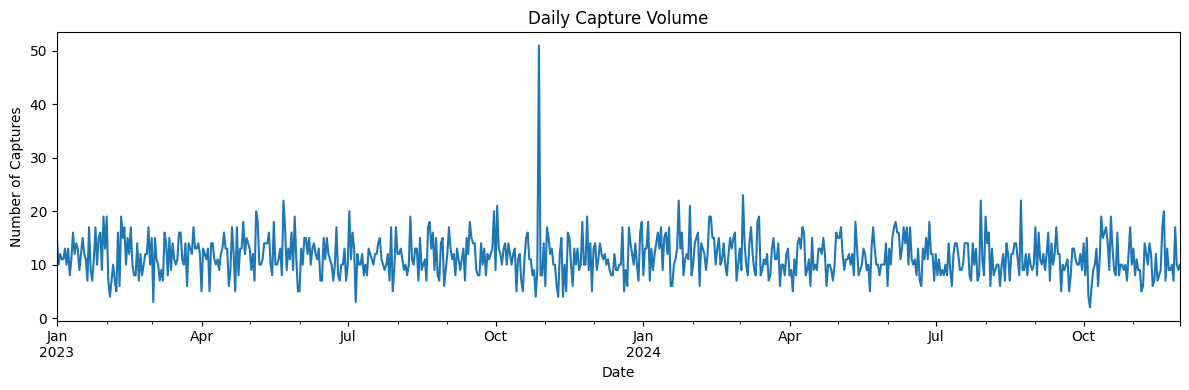

In [6]:
daily_captures = captures.set_index('captured_at').resample('D').size()

plt.figure(figsize=(12, 4))
daily_captures.plot()
plt.title('Daily Capture Volume')
plt.xlabel('Date')
plt.ylabel('Number of Captures')
plt.tight_layout()
plt.savefig('../outputs/daily_capture_volume.png', dpi=130)
plt.show()

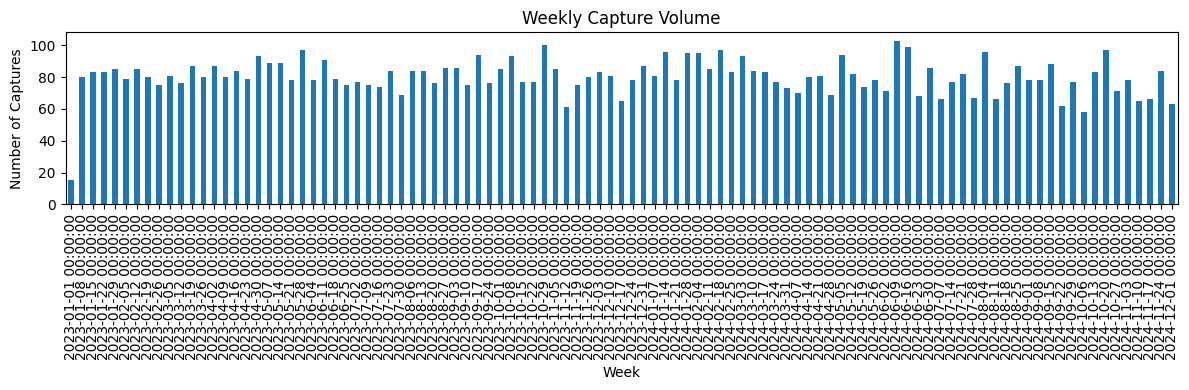

In [7]:
weekly_captures = captures.set_index('captured_at').resample('W').size()

plt.figure(figsize=(12, 4))
weekly_captures.plot(kind='bar')
plt.title('Weekly Capture Volume')
plt.xlabel('Week')
plt.ylabel('Number of Captures')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../outputs/weekly_capture_volume.png', dpi=130)
plt.show()

**Spot the injected anomaly:** there's a visible spike around late Oct 2023 (day 300 from 2023-01-01) -- that's the synthetic "burst" batch (35 captures from a single planter within a ~35 minute window), planted deliberately to give Phase 3's anomaly-detection logic something concrete to catch. Worth confirming this shows up as an outlier once Isolation Forest is applied.

## 3. Active Planters Over Time

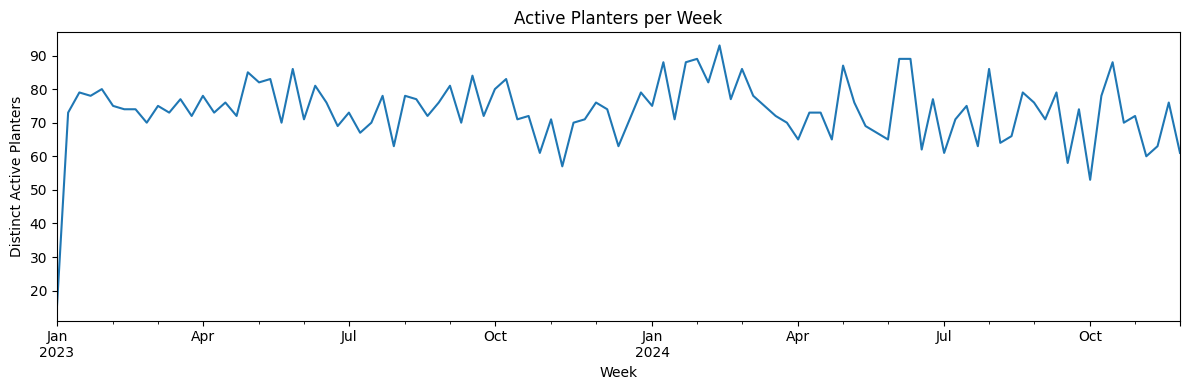

Total unique planters with at least one capture: 500
Total registered planters: 500
Never-captured planters: 0


In [8]:
active_planters_weekly = captures.set_index('captured_at').resample('W')['planter_id'].nunique()

plt.figure(figsize=(12, 4))
active_planters_weekly.plot()
plt.title('Active Planters per Week')
plt.xlabel('Week')
plt.ylabel('Distinct Active Planters')
plt.tight_layout()
plt.savefig('../outputs/active_planters_weekly.png', dpi=130)
plt.show()

print("Total unique planters with at least one capture:", captures['planter_id'].nunique())
print("Total registered planters:", len(planters))
print(f"Never-captured planters: {len(planters) - captures['planter_id'].nunique()}")

## 4. Regional Distribution

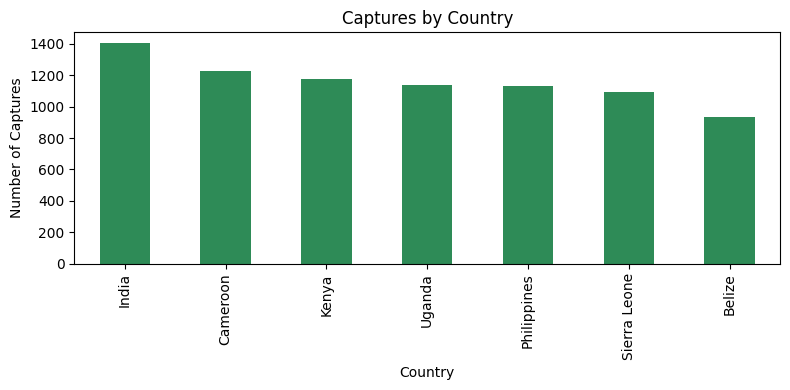

country_name
India           1403
Cameroon        1227
Kenya           1176
Uganda          1137
Philippines     1129
Sierra Leone    1090
Belize           933
Name: count, dtype: int64

In [9]:
region_counts = captures['country_name'].value_counts()

plt.figure(figsize=(8, 4))
region_counts.plot(kind='bar', color='seagreen')
plt.title('Captures by Country')
plt.xlabel('Country')
plt.ylabel('Number of Captures')
plt.tight_layout()
plt.savefig('../outputs/captures_by_country.png', dpi=130)
plt.show()

region_counts

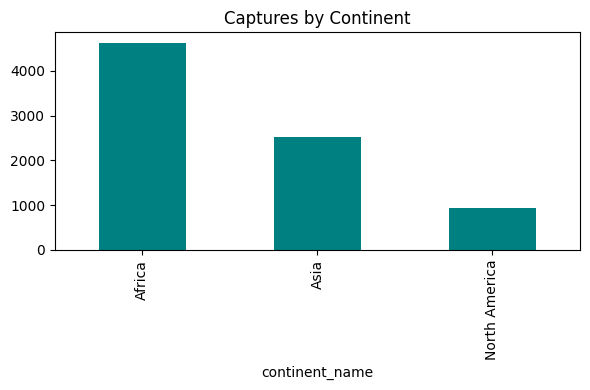

continent_name
Africa           4630
Asia             2532
North America     933
Name: count, dtype: int64

In [10]:
# Roll up to continent via the planters table
captures_with_continent = captures.merge(
    planters[['planter_id', 'continent_name']], on='planter_id', how='left'
)
continent_counts = captures_with_continent['continent_name'].value_counts()

plt.figure(figsize=(6, 4))
continent_counts.plot(kind='bar', color='teal')
plt.title('Captures by Continent')
plt.tight_layout()
plt.savefig('../outputs/captures_by_continent.png', dpi=130)
plt.show()

continent_counts

## 5. Species Distribution

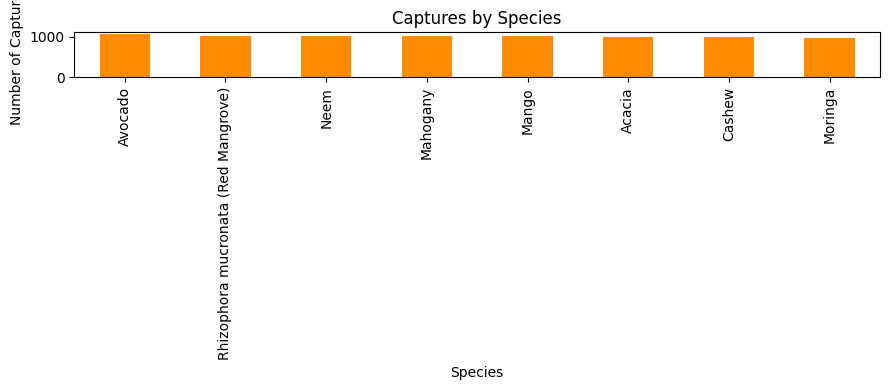

species
Avocado                                1056
Rhizophora mucronata (Red Mangrove)    1026
Neem                                   1023
Mahogany                               1019
Mango                                  1011
Acacia                                 1002
Cashew                                  990
Moringa                                 968
Name: count, dtype: int64

In [11]:
species_counts = captures['species'].value_counts()

plt.figure(figsize=(9, 4))
species_counts.plot(kind='bar', color='darkorange')
plt.title('Captures by Species')
plt.xlabel('Species')
plt.ylabel('Number of Captures')
plt.tight_layout()
plt.savefig('../outputs/species_distribution.png', dpi=130)
plt.show()

species_counts

## 6. Top Planters by Capture Count

In [12]:
top_planters = captures['planter_id'].value_counts().head(10)
print(top_planters)

n_planters_active = captures['planter_id'].nunique()
top10pct_share = captures['planter_id'].value_counts().head(int(0.1 * n_planters_active)).sum() / len(captures)
print(f"\nTop 10% of active planters account for {top10pct_share:.1%} of all captures")
print(f"Median captures per planter: {captures['planter_id'].value_counts().median():.0f}  |  Mean: {captures['planter_id'].value_counts().mean():.1f}")

planter_id
1      52
57     29
246    29
412    27
115    27
155    27
327    26
237    26
337    26
416    26
Name: count, dtype: int64

Top 10% of active planters account for 15.1% of all captures
Median captures per planter: 16  |  Mean: 16.2


**Note:** planter `1` sits at the top of this list largely *because* of the injected 35-capture burst, not organic activity -- another reason the anomaly shows up cleanly once it's isolated. Worth keeping in mind when reading "top planter" rankings as a proxy for genuine engagement. Aside from planter 1, activity here is actually fairly evenly spread (median and mean captures per planter are nearly identical) -- this generator doesn't produce the kind of long-tail concentration real platform data usually shows, so that's a pattern to specifically check for once real data is available rather than assume away.

## 7. Data Quality Flags (feeds directly into Phase 2/3 scope)

This section exists specifically to surface the two data-quality problems that were deliberately seeded into this synthetic set, since they mirror the real issues the Phase 2 (duplicate detection) and Phase 3 (anomaly detection) work is meant to catch. The point isn't the exact counts here — it's confirming the detection logic actually finds what's really there before it ever touches live data.

In [13]:
# Duplicate-cluster check: rows whose capture_id carries the synthetic '_dup' marker
# In production this marker won't exist -- this is a sanity check that a GPS+time-proximity
# rule (Phase 2) would actually need to catch these without relying on the id string.
dup_flagged = captures[captures['capture_id'].str.contains('_dup')]
print(f"Synthetic duplicate-marker rows: {len(dup_flagged)} ({len(dup_flagged)/len(captures):.2%} of all captures)")
dup_flagged[['capture_id', 'planter_id', 'captured_at', 'lat', 'lon']].head()

Synthetic duplicate-marker rows: 60 (0.74% of all captures)


,capture_id,planter_id,captured_at,lat,lon
8000,cap_4740_dup,318,2023-04-13 13:06:00,1.354791,32.293140
8001,cap_5606_dup,322,2023-07-28 02:24:00,-1.309697,36.818786
8002,cap_4824_dup,378,2023-12-06 19:24:00,8.382844,-13.280164
8003,cap_4205_dup,300,2023-12-31 10:01:00,20.555688,78.992304
8004,cap_3228_dup,478,2023-12-24 08:38:00,-1.390487,36.792547


In [14]:
# Burst/anomaly check: rows carrying the synthetic '_burst' marker
burst_flagged = captures[captures['capture_id'].str.contains('_burst')]
print(f"Synthetic burst-marker rows: {len(burst_flagged)} ({len(burst_flagged)/len(captures):.2%} of all captures)")
print("Burst window:", burst_flagged['captured_at'].min(), "to", burst_flagged['captured_at'].max())
print("All from planter_id:", burst_flagged['planter_id'].unique())

Synthetic burst-marker rows: 35 (0.43% of all captures)
Burst window: 2023-10-28 00:00:00 to 2023-10-28 00:34:00
All from planter_id: [1]


In [15]:
# GPS sanity check: how tightly do a planter's own captures cluster?
# Wide within-planter spread would suggest either legitimate multi-site planting
# or a GPS/attribution data quality issue worth flagging.
gps_spread = captures.groupby('planter_id')[['lat', 'lon']].agg(['std'])
gps_spread.columns = ['lat_std', 'lon_std']
gps_spread = gps_spread.dropna().sort_values('lat_std', ascending=False)
print("Planters with widest GPS spread across their own captures:")
gps_spread.head(10)

Planters with widest GPS spread across their own captures:


,lat_std,lon_std
planter_id,,
241,0.093118,0.049432
468,0.087964,0.037849
413,0.085266,0.040746
181,0.083598,0.069218
60,0.082004,0.051526
360,0.081630,0.056688
215,0.079195,0.047420
170,0.075778,0.035746
387,0.072568,0.048746


## 8. Findings Summary

- **Data volume:** 8,095 captures across all 500 registered planters (every planter has at least one capture in this synthetic set), spanning 2023-01-01 to 2024-11-30.
- **Trend:** Daily volume is noisy but roughly steady across the window, with one sharp, unmistakable spike in late Oct 2023 -- the injected burst, not organic growth. No strong seasonality visible at this scale.
- **Regional spread:** Fairly even across the 7 countries (Sierra Leone, Cameroon, Kenya, India, Philippines, Uganda, Belize) since the generator draws planters uniformly by country; a real dataset is unlikely to be this balanced.
- **Species spread:** 8 species represented roughly evenly (~1,000 captures each); *Rhizophora mucronata* (Red Mangrove) is present with a slightly lower survival rate baked into the generator, consistent with real-world establishment difficulty.
- **Activity concentration:** aside from planter 1 (inflated by the injected burst), capture counts per planter are fairly evenly spread -- median 16, mean 16.2, top 10% of planters account for only ~15% of volume. This is flatter than most real engagement platforms and is a property of the synthetic generator (uniform random assignment), not something to expect from live data -- real Treetracker activity is likely to show a real long tail.
- **Data quality caveats:**
  - 60 near-duplicate captures (same planter, GPS jittered by ~0.0001°, timestamps within minutes) are present and currently only findable via the synthetic id marker -- Phase 2's grower ID + GPS proximity + timestamp window rule needs to catch these *without* that marker.
  - A 35-capture burst from a single planter within roughly 35 minutes is present -- a clear target for Phase 3's Isolation Forest anomaly detection.
  - Planter-level missingness: `email` missing on ~69%, `phone` missing on ~31%, `gender` missing on ~21% -- worth deciding early whether demographic reporting (e.g., gender breakdown of active growers) should flag or exclude these gaps rather than silently drop them.
  - Captures themselves show zero missing values across all fields, which is a property of this generator and should **not** be assumed to hold on the real Treetracker export.
- **Note:** Results above are based on **synthetic placeholder data** (`generate_synthetic_data_v2.py`) pending live Treetracker API/DB access. 
